# Transaction Cost Rebalancing Analysis

In this notebook, we extend the rebalancing analysis by including transaction costs.

The objective is to understand how trading costs affect portfolio performance under different rebalancing frequencies.

We compare:

- Buy & Hold
- Monthly Rebalancing
- Quarterly Rebalancing
- Annual Rebalancing

under different transaction cost assumptions.

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project folders
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

# Portfolio allocations
portfolios = {
    "Conservative": {
        "SPY": 0.20,
        "QQQ": 0.10,
        "TLT": 0.50,
        "GLD": 0.20
    },
    "Balanced": {
        "SPY": 0.40,
        "QQQ": 0.30,
        "TLT": 0.20,
        "GLD": 0.10
    },
    "Aggressive": {
        "SPY": 0.50,
        "QQQ": 0.40,
        "TLT": 0.05,
        "GLD": 0.05
    }
}

assets = returns.columns
initial_portfolio_value = 10_000
trading_days = 252
risk_free_rate = 0.00

print("Setup completed.")
print(f"Returns shape: {returns.shape}")
print(f"Assets: {list(assets)}")
print(f"Portfolios: {list(portfolios.keys())}")

returns.head()

Setup completed.
Returns shape: (2137, 4)
Assets: ['GLD', 'QQQ', 'SPY', 'TLT']
Portfolios: ['Conservative', 'Balanced', 'Aggressive']


,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [19]:
def get_rebalance_dates(returns_index, frequency):
    """
    Returns the last available trading day for each rebalancing period.
    
    frequency can be:
    - "M" for monthly
    - "Q" for quarterly
    - "Y" for annual
    """
    return returns_index.to_series().groupby(
        returns_index.to_period(frequency)
    ).tail(1).index


def simulate_rebalanced_portfolio_with_costs(
    returns,
    weights_dict,
    initial_value=10_000,
    rebalance_frequency=None,
    transaction_cost_rate=0.00
):
    """
    Simulates portfolio value over time with optional rebalancing and transaction costs.

    transaction_cost_rate example:
    0.001 = 0.10% per dollar traded
    """
    weights = pd.Series(weights_dict)
    weights = weights[returns.columns]

    asset_values = weights * initial_value
    portfolio_values = []
    transaction_costs = []

    if rebalance_frequency is not None:
        rebalance_dates = set(get_rebalance_dates(returns.index, rebalance_frequency))
    else:
        rebalance_dates = set()

    for date, daily_return in returns.iterrows():
        asset_values = asset_values * (1 + daily_return)

        daily_transaction_cost = 0.00

        if date in rebalance_dates:
            total_value_before_cost = asset_values.sum()
            target_asset_values = weights * total_value_before_cost

            trades = target_asset_values - asset_values
            dollar_turnover = trades.abs().sum()

            daily_transaction_cost = dollar_turnover * transaction_cost_rate

            total_value_after_cost = total_value_before_cost - daily_transaction_cost
            asset_values = weights * total_value_after_cost

        portfolio_values.append(asset_values.sum())
        transaction_costs.append(daily_transaction_cost)

    portfolio_values = pd.Series(
        portfolio_values,
        index=returns.index,
        name="Portfolio Value"
    )

    transaction_costs = pd.Series(
        transaction_costs,
        index=returns.index,
        name="Transaction Costs"
    )

    return portfolio_values, transaction_costs

In [20]:
def calculate_performance_metrics(portfolio_values, transaction_costs, risk_free_rate=0.00):
    """
    Calculates performance and risk metrics.
    """
    daily_returns = portfolio_values.pct_change().dropna()

    final_value = portfolio_values.iloc[-1]
    total_return = final_value / portfolio_values.iloc[0] - 1

    annualized_return = (final_value / portfolio_values.iloc[0]) ** (
        trading_days / len(daily_returns)
    ) - 1

    annualized_volatility = daily_returns.std() * np.sqrt(trading_days)

    sharpe_ratio = (
        (annualized_return - risk_free_rate) / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    )

    running_max = portfolio_values.cummax()
    drawdown = portfolio_values / running_max - 1
    max_drawdown = drawdown.min()

    total_transaction_costs = transaction_costs.sum()

    return {
        "Final Value": final_value,
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown,
        "Total Transaction Costs": total_transaction_costs
    }

In [21]:
rebalancing_strategies = {
    "Buy & Hold": None,
    "Monthly Rebalancing": "M",
    "Quarterly Rebalancing": "Q",
    "Annual Rebalancing": "Y"
}

transaction_cost_rates = {
    "0.00%": 0.0000,
    "0.05%": 0.0005,
    "0.10%": 0.0010,
    "0.25%": 0.0025
}

transaction_cost_results = []
transaction_cost_paths = {}

for portfolio_name, allocation in portfolios.items():
    transaction_cost_paths[portfolio_name] = {}

    for strategy_name, frequency in rebalancing_strategies.items():
        transaction_cost_paths[portfolio_name][strategy_name] = {}

        for cost_label, cost_rate in transaction_cost_rates.items():
            values, costs = simulate_rebalanced_portfolio_with_costs(
                returns=returns,
                weights_dict=allocation,
                initial_value=initial_portfolio_value,
                rebalance_frequency=frequency,
                transaction_cost_rate=cost_rate
            )

            metrics = calculate_performance_metrics(
                values,
                costs,
                risk_free_rate=risk_free_rate
            )

            metrics["Portfolio"] = portfolio_name
            metrics["Strategy"] = strategy_name
            metrics["Transaction Cost Rate"] = cost_label

            transaction_cost_results.append(metrics)

            transaction_cost_paths[portfolio_name][strategy_name][cost_label] = values

transaction_cost_summary = pd.DataFrame(transaction_cost_results)

transaction_cost_summary = transaction_cost_summary[
    [
        "Portfolio",
        "Strategy",
        "Transaction Cost Rate",
        "Final Value",
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Total Transaction Costs"
    ]
]

transaction_cost_summary.to_csv(
    OUTPUTS_DIR / "transaction_cost_rebalancing_summary.csv",
    index=False
)

transaction_cost_summary

,Portfolio,Strategy,Transaction Cost Rate,Final Value,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Total Transaction Costs
0,Conservative,Buy & Hold,0.00%,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633,0.000000
1,Conservative,Buy & Hold,0.05%,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633,0.000000
2,Conservative,Buy & Hold,0.10%,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633,0.000000
3,Conservative,Buy & Hold,0.25%,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633,0.000000
4,Conservative,Monthly Rebalancing,0.00%,17894.404954,0.782134,0.070546,0.106583,0.661887,-0.278100,0.000000
5,Conservative,Monthly Rebalancing,0.05%,17872.281931,0.779930,0.070390,0.106583,0.660419,-0.278193,16.798284
6,Conservative,Monthly Rebalancing,0.10%,17850.185915,0.777730,0.070233,0.106584,0.658951,-0.278286,33.574383
7,Conservative,Monthly Rebalancing,0.25%,17784.059576,0.771144,0.069765,0.106585,0.654548,-0.278564,83.769842
8,Conservative,Quarterly Rebalancing,0.00%,18144.694427,0.807060,0.072302,0.106894,0.676388,-0.278773,0.000000
9,Conservative,Quarterly Rebalancing,0.05%,18130.305570,0.805627,0.072201,0.106894,0.675446,-0.278825,10.945499


In [22]:
# Calculate cost drag relative to the zero-cost version of each portfolio and strategy
zero_cost_reference = transaction_cost_summary[
    transaction_cost_summary["Transaction Cost Rate"] == "0.00%"
][
    ["Portfolio", "Strategy", "Final Value"]
].rename(columns={"Final Value": "Zero Cost Final Value"})

transaction_cost_summary_with_drag = transaction_cost_summary.merge(
    zero_cost_reference,
    on=["Portfolio", "Strategy"],
    how="left"
)

transaction_cost_summary_with_drag["Cost Drag"] = (
    transaction_cost_summary_with_drag["Zero Cost Final Value"]
    - transaction_cost_summary_with_drag["Final Value"]
)

transaction_cost_summary_with_drag.to_csv(
    OUTPUTS_DIR / "transaction_cost_rebalancing_summary_with_drag.csv",
    index=False
)

transaction_cost_summary_with_drag

,Portfolio,Strategy,Transaction Cost Rate,Final Value,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Total Transaction Costs,Zero Cost Final Value,Cost Drag
0,Conservative,Buy & Hold,0.00%,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633,0.000000,21379.995969,0.000000
1,Conservative,Buy & Hold,0.05%,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633,0.000000,21379.995969,0.000000
2,Conservative,Buy & Hold,0.10%,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633,0.000000,21379.995969,0.000000
3,Conservative,Buy & Hold,0.25%,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633,0.000000,21379.995969,0.000000
4,Conservative,Monthly Rebalancing,0.00%,17894.404954,0.782134,0.070546,0.106583,0.661887,-0.278100,0.000000,17894.404954,0.000000
5,Conservative,Monthly Rebalancing,0.05%,17872.281931,0.779930,0.070390,0.106583,0.660419,-0.278193,16.798284,17894.404954,22.123023
6,Conservative,Monthly Rebalancing,0.10%,17850.185915,0.777730,0.070233,0.106584,0.658951,-0.278286,33.574383,17894.404954,44.219040
7,Conservative,Monthly Rebalancing,0.25%,17784.059576,0.771144,0.069765,0.106585,0.654548,-0.278564,83.769842,17894.404954,110.345378
8,Conservative,Quarterly Rebalancing,0.00%,18144.694427,0.807060,0.072302,0.106894,0.676388,-0.278773,0.000000,18144.694427,0.000000
9,Conservative,Quarterly Rebalancing,0.05%,18130.305570,0.805627,0.072201,0.106894,0.675446,-0.278825,10.945499,18144.694427,14.388857


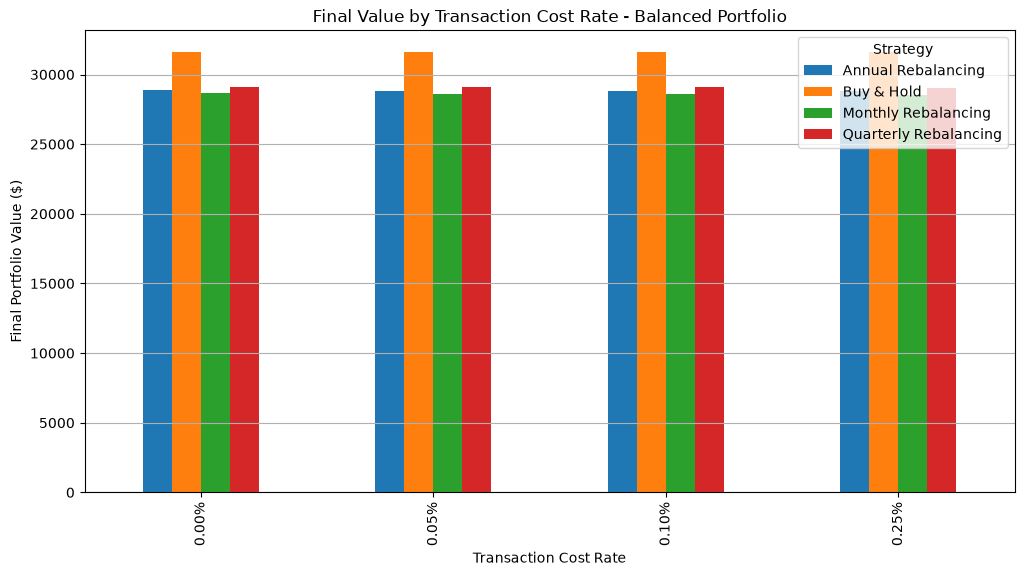

In [23]:
balanced_summary = transaction_cost_summary_with_drag[
    transaction_cost_summary_with_drag["Portfolio"] == "Balanced"
]

balanced_final_value_pivot = balanced_summary.pivot(
    index="Transaction Cost Rate",
    columns="Strategy",
    values="Final Value"
)

ax = balanced_final_value_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Final Value by Transaction Cost Rate - Balanced Portfolio")
plt.xlabel("Transaction Cost Rate")
plt.ylabel("Final Portfolio Value ($)")
plt.grid(axis="y")
plt.legend(title="Strategy")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "transaction_cost_final_value_balanced.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

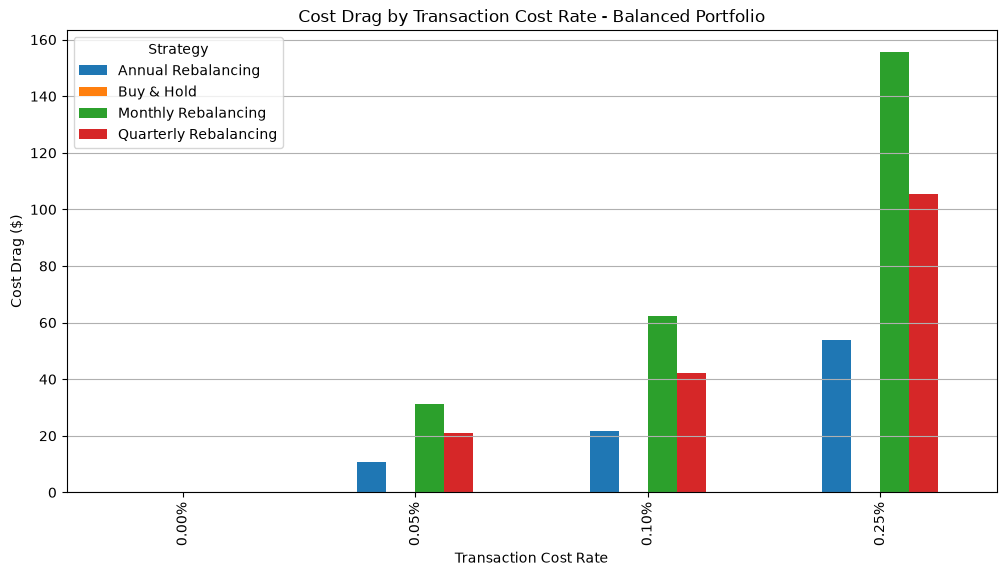

In [24]:
balanced_cost_drag_pivot = balanced_summary.pivot(
    index="Transaction Cost Rate",
    columns="Strategy",
    values="Cost Drag"
)

ax = balanced_cost_drag_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Cost Drag by Transaction Cost Rate - Balanced Portfolio")
plt.xlabel("Transaction Cost Rate")
plt.ylabel("Cost Drag ($)")
plt.grid(axis="y")
plt.legend(title="Strategy")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "transaction_cost_drag_balanced.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

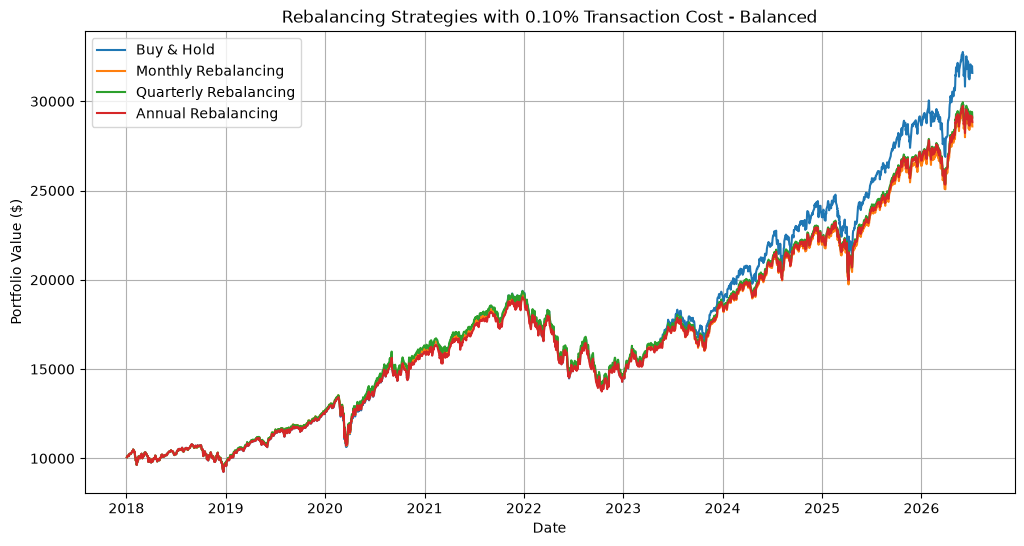

In [25]:
selected_portfolio = "Balanced"
selected_cost = "0.10%"

plt.figure(figsize=(12, 6))

for strategy_name in rebalancing_strategies.keys():
    values = transaction_cost_paths[selected_portfolio][strategy_name][selected_cost]
    plt.plot(values.index, values, label=strategy_name)

plt.title(f"Rebalancing Strategies with {selected_cost} Transaction Cost - {selected_portfolio}")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "transaction_cost_rebalancing_paths_balanced_010.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Quick Note

The analysis shown above is a simplified view of the transaction cost impact, focused specifically on the Balanced Portfolio.

The full analysis includes all combinations of portfolios, rebalancing strategies, and transaction cost assumptions. In the following section, we extend the comparison to all simulated cases in order to evaluate the broader impact of transaction costs across different portfolio profiles.

In [27]:
# Best strategy by final value for each portfolio and transaction cost rate
best_strategy_by_final_value = transaction_cost_summary_with_drag.loc[
    transaction_cost_summary_with_drag.groupby(
        ["Portfolio", "Transaction Cost Rate"]
    )["Final Value"].idxmax()
]

best_strategy_by_final_value = best_strategy_by_final_value[
    [
        "Portfolio",
        "Transaction Cost Rate",
        "Strategy",
        "Final Value",
        "Total Return",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Total Transaction Costs",
        "Cost Drag"
    ]
]

best_strategy_by_final_value.to_csv(
    OUTPUTS_DIR / "best_rebalancing_strategy_by_final_value.csv",
    index=False
)

best_strategy_by_final_value

,Portfolio,Transaction Cost Rate,Strategy,Final Value,Total Return,Sharpe Ratio,Maximum Drawdown,Total Transaction Costs,Cost Drag
32,Aggressive,0.00%,Buy & Hold,36691.642822,2.643092,0.845835,-0.293284,0.0,0.0
33,Aggressive,0.05%,Buy & Hold,36691.642822,2.643092,0.845835,-0.293284,0.0,0.0
34,Aggressive,0.10%,Buy & Hold,36691.642822,2.643092,0.845835,-0.293284,0.0,0.0
35,Aggressive,0.25%,Buy & Hold,36691.642822,2.643092,0.845835,-0.293284,0.0,0.0
16,Balanced,0.00%,Buy & Hold,31587.760538,2.139506,0.899516,-0.287108,0.0,0.0
17,Balanced,0.05%,Buy & Hold,31587.760538,2.139506,0.899516,-0.287108,0.0,0.0
18,Balanced,0.10%,Buy & Hold,31587.760538,2.139506,0.899516,-0.287108,0.0,0.0
19,Balanced,0.25%,Buy & Hold,31587.760538,2.139506,0.899516,-0.287108,0.0,0.0
0,Conservative,0.00%,Buy & Hold,21379.995969,1.129269,0.828399,-0.274633,0.0,0.0
1,Conservative,0.05%,Buy & Hold,21379.995969,1.129269,0.828399,-0.274633,0.0,0.0


In [28]:
# Best strategy by Sharpe Ratio for each portfolio and transaction cost rate
best_strategy_by_sharpe = transaction_cost_summary_with_drag.loc[
    transaction_cost_summary_with_drag.groupby(
        ["Portfolio", "Transaction Cost Rate"]
    )["Sharpe Ratio"].idxmax()
]

best_strategy_by_sharpe = best_strategy_by_sharpe[
    [
        "Portfolio",
        "Transaction Cost Rate",
        "Strategy",
        "Final Value",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Total Transaction Costs",
        "Cost Drag"
    ]
]

best_strategy_by_sharpe.to_csv(
    OUTPUTS_DIR / "best_rebalancing_strategy_by_sharpe.csv",
    index=False
)

best_strategy_by_sharpe

,Portfolio,Transaction Cost Rate,Strategy,Final Value,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Total Transaction Costs,Cost Drag
44,Aggressive,0.00%,Annual Rebalancing,35861.632103,0.161632,0.187475,0.862150,-0.282972,0.000000,0.000000
45,Aggressive,0.05%,Annual Rebalancing,35852.285517,0.161596,0.187476,0.861958,-0.282989,5.295603,9.346586
46,Aggressive,0.10%,Annual Rebalancing,35842.940991,0.161560,0.187476,0.861765,-0.283005,10.589812,18.691112
47,Aggressive,0.25%,Annual Rebalancing,35814.919767,0.161453,0.187477,0.861188,-0.283056,26.464077,46.712336
24,Balanced,0.00%,Quarterly Rebalancing,29129.638205,0.133620,0.147169,0.907934,-0.278688,0.000000,0.000000
25,Balanced,0.05%,Quarterly Rebalancing,29108.484439,0.133523,0.147169,0.907279,-0.278736,12.411628,21.153766
26,Balanced,0.10%,Quarterly Rebalancing,29087.345401,0.133426,0.147168,0.906624,-0.278783,24.812960,42.292804
27,Balanced,0.25%,Quarterly Rebalancing,29024.016557,0.133135,0.147166,0.904658,-0.278927,61.955254,105.621648
0,Conservative,0.00%,Buy & Hold,21379.995969,0.093261,0.112580,0.828399,-0.274633,0.000000,0.000000
1,Conservative,0.05%,Buy & Hold,21379.995969,0.093261,0.112580,0.828399,-0.274633,0.000000,0.000000


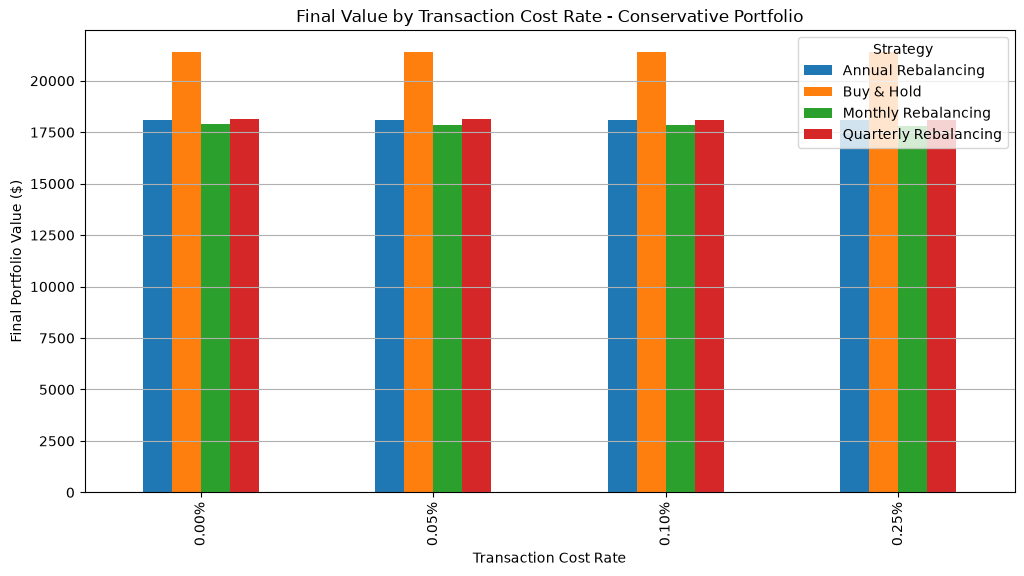

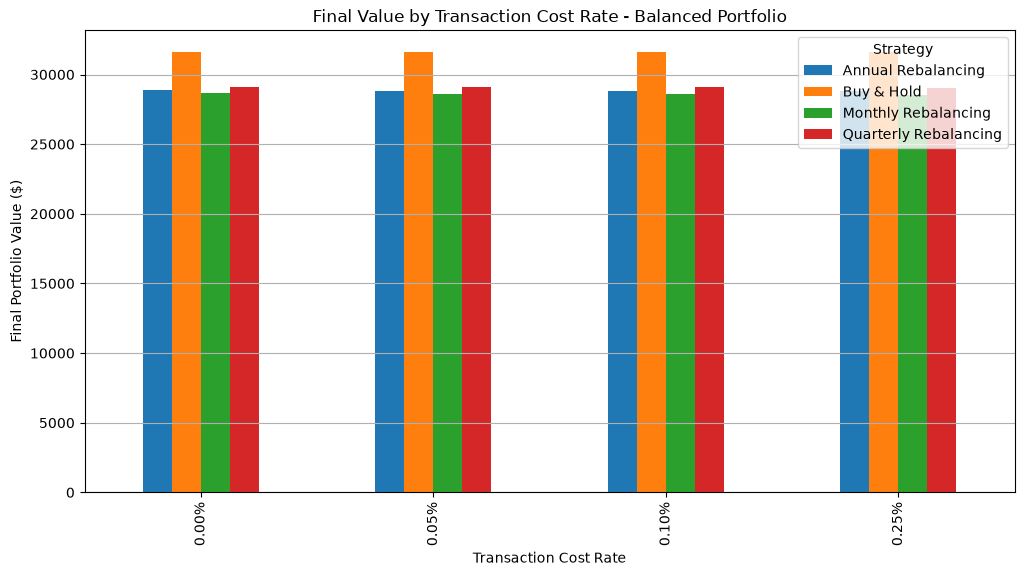

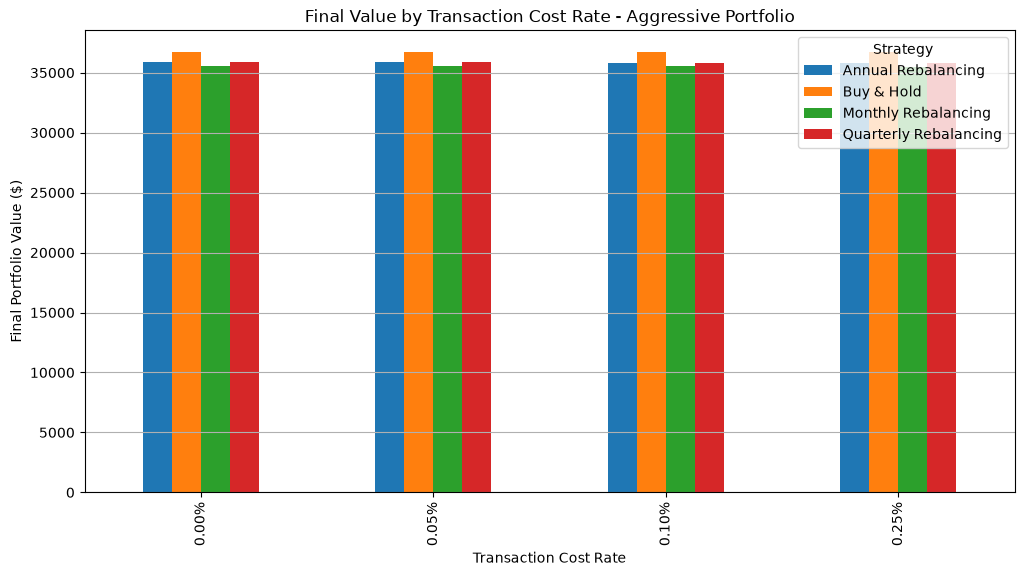

In [30]:
# Final value comparison for all portfolios
for portfolio_name in transaction_cost_summary_with_drag["Portfolio"].unique():
    portfolio_data = transaction_cost_summary_with_drag[
        transaction_cost_summary_with_drag["Portfolio"] == portfolio_name
    ]

    final_value_pivot = portfolio_data.pivot(
        index="Transaction Cost Rate",
        columns="Strategy",
        values="Final Value"
    )

    ax = final_value_pivot.plot(kind="bar", figsize=(12, 6))

    plt.title(f"Final Value by Transaction Cost Rate - {portfolio_name} Portfolio")
    plt.xlabel("Transaction Cost Rate")
    plt.ylabel("Final Portfolio Value ($)")
    plt.grid(axis="y")
    plt.legend(title="Strategy")

    fig = ax.get_figure()
    fig.savefig(
        IMAGES_DIR / f"transaction_cost_final_value_{portfolio_name.lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

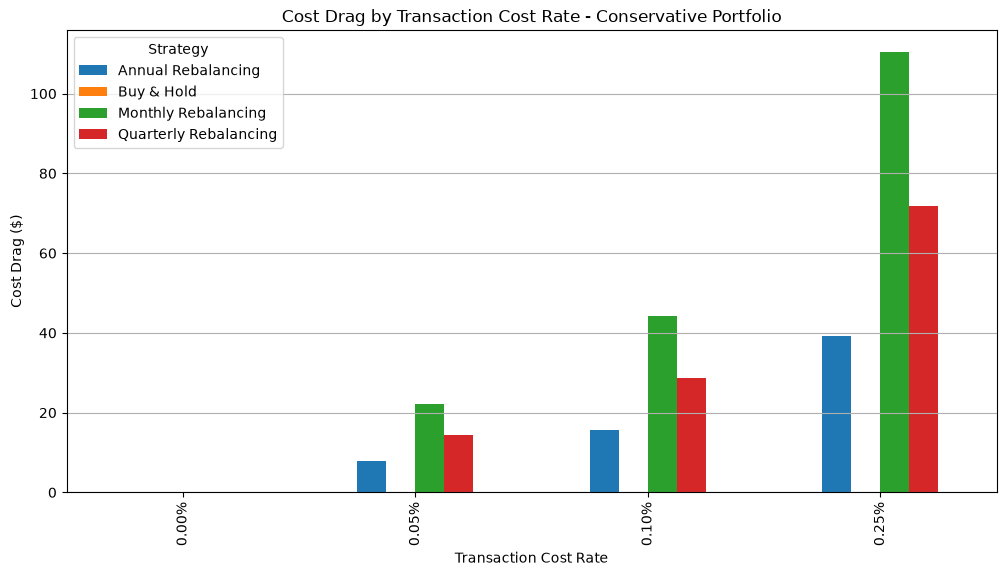

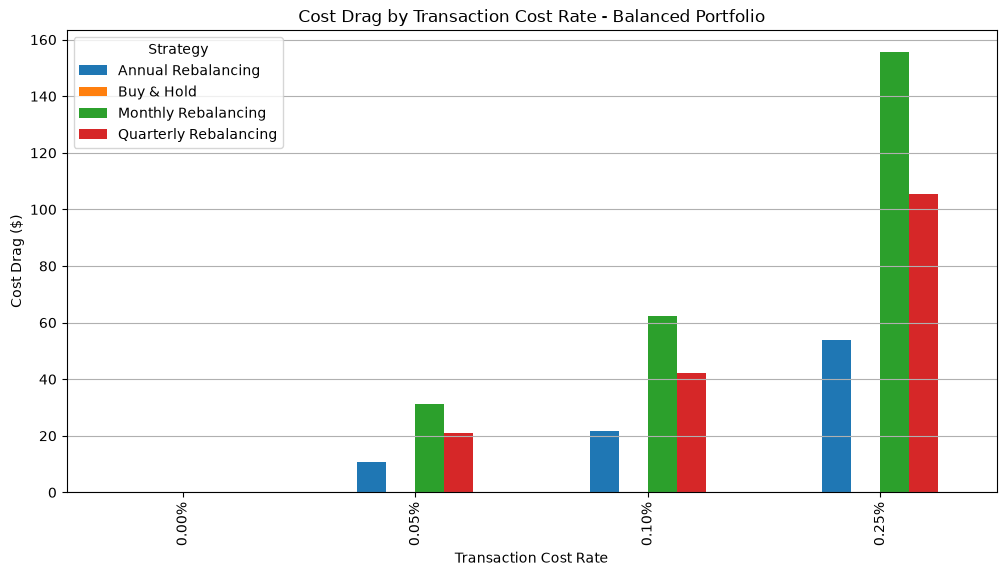

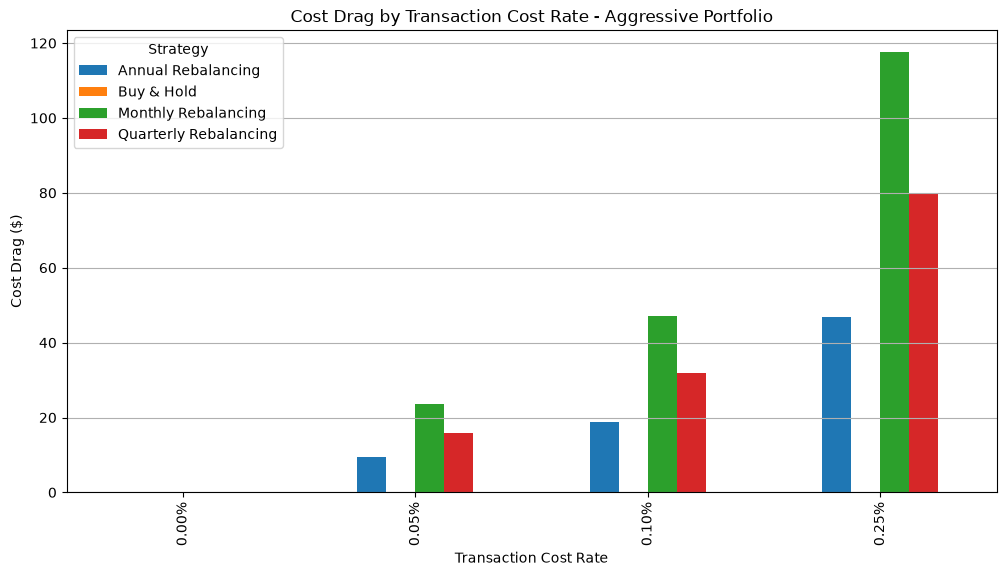

In [31]:
# Cost drag comparison for all portfolios
for portfolio_name in transaction_cost_summary_with_drag["Portfolio"].unique():
    portfolio_data = transaction_cost_summary_with_drag[
        transaction_cost_summary_with_drag["Portfolio"] == portfolio_name
    ]

    cost_drag_pivot = portfolio_data.pivot(
        index="Transaction Cost Rate",
        columns="Strategy",
        values="Cost Drag"
    )

    ax = cost_drag_pivot.plot(kind="bar", figsize=(12, 6))

    plt.title(f"Cost Drag by Transaction Cost Rate - {portfolio_name} Portfolio")
    plt.xlabel("Transaction Cost Rate")
    plt.ylabel("Cost Drag ($)")
    plt.grid(axis="y")
    plt.legend(title="Strategy")

    fig = ax.get_figure()
    fig.savefig(
        IMAGES_DIR / f"transaction_cost_drag_{portfolio_name.lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [32]:
# Compact summary of best strategies by Sharpe Ratio
compact_best_summary = best_strategy_by_sharpe[
    [
        "Portfolio",
        "Transaction Cost Rate",
        "Strategy",
        "Final Value",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Cost Drag"
    ]
].copy()

compact_best_summary.to_csv(
    OUTPUTS_DIR / "compact_best_rebalancing_summary.csv",
    index=False
)

compact_best_summary

,Portfolio,Transaction Cost Rate,Strategy,Final Value,Sharpe Ratio,Maximum Drawdown,Cost Drag
44,Aggressive,0.00%,Annual Rebalancing,35861.632103,0.862150,-0.282972,0.000000
45,Aggressive,0.05%,Annual Rebalancing,35852.285517,0.861958,-0.282989,9.346586
46,Aggressive,0.10%,Annual Rebalancing,35842.940991,0.861765,-0.283005,18.691112
47,Aggressive,0.25%,Annual Rebalancing,35814.919767,0.861188,-0.283056,46.712336
24,Balanced,0.00%,Quarterly Rebalancing,29129.638205,0.907934,-0.278688,0.000000
25,Balanced,0.05%,Quarterly Rebalancing,29108.484439,0.907279,-0.278736,21.153766
26,Balanced,0.10%,Quarterly Rebalancing,29087.345401,0.906624,-0.278783,42.292804
27,Balanced,0.25%,Quarterly Rebalancing,29024.016557,0.904658,-0.278927,105.621648
0,Conservative,0.00%,Buy & Hold,21379.995969,0.828399,-0.274633,0.000000
1,Conservative,0.05%,Buy & Hold,21379.995969,0.828399,-0.274633,0.000000


## Transaction Cost Rebalancing Interpretation

This analysis shows that rebalancing frequency should be evaluated together with transaction costs.

Without transaction costs, frequent rebalancing can help maintain the target allocation and control portfolio drift.

However, when transaction costs are introduced, more frequent rebalancing can reduce final portfolio value because the portfolio trades more often.

Monthly rebalancing is usually more sensitive to transaction costs, while quarterly or annual rebalancing may offer a better balance between maintaining diversification and limiting trading costs.

Buy & Hold has no rebalancing transaction costs, but it allows portfolio weights to drift over time, which may increase concentration risk.

The best strategy depends on whether the investor prioritizes final value, Sharpe Ratio, maximum drawdown control, or implementation cost efficiency.

Overall, this notebook makes the rebalancing analysis more realistic by showing that portfolio management decisions depend not only on returns and risk, but also on implementation costs.